# 웹 검색 모듈 추가

이번 튜토리얼에서는 RAG 파이프라인에 **웹 검색(Web Search)** 기능을 추가합니다.

> 참고 문서: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)

**학습 목표**

- Tavily Search를 활용한 웹 검색 방법을 학습합니다.
- 관련성 체크 실패 시 웹 검색으로 폴백하는 흐름을 구현합니다.
- 재귀 상태 없이 안정적인 RAG 파이프라인을 구축합니다.

**참고**

- 이전 튜토리얼에서 확장된 내용이므로, 겹치는 부분은 간략히 설명합니다.

![langgraph-web-search](assets/langgraph-web-search.png)

## 환경 설정

먼저 필요한 환경 변수를 로드하고 LangSmith 추적을 설정합니다. `.env` 파일에는 사용할 LLM 제공자의 API 키가 저장되어 있어야 합니다. LangSmith 추적을 활성화하면 그래프 실행 과정을 시각적으로 디버깅할 수 있습니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-RAG")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-RAG


## PDF 기반 Retrieval Chain 생성

PDF 문서를 기반으로 Retrieval Chain을 생성합니다. LangGraph에서는 Retriever와 Chain을 분리하여 각 노드에서 세부 처리를 수행할 수 있습니다. 이 구조를 활용하면 검색과 생성 사이에 관련성 체크나 웹 검색 같은 중간 단계를 자연스럽게 삽입할 수 있습니다.

**사용 문서**

- 소프트웨어정책연구소(SPRi) - 2023년 12월호
- 파일명: `SPRI_AI_Brief_2023년12월호_F.pdf`

아래 코드는 PDF 문서를 로드하고 Retriever와 Chain을 생성합니다.

In [3]:
from rag.pdf import PDFRetrievalChain

# PDF 문서를 로드합니다.
pdf = PDFRetrievalChain(["data/SPRI_AI_Brief_2023년12월호_F.pdf"]).create_chain()

# retriever와 chain을 생성합니다.
pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

Cache configured for multi-PDF processing
Loading PDF: data/SPRI_AI_Brief_2023년12월호_F.pdf
Successfully loaded 23 pages from: data/SPRI_AI_Brief_2023년12월호_F.pdf

Loading Summary:
- Successfully loaded: 1 files
- Failed to load: 0 files
- Total documents loaded: 23
FAISS index saved to cache


## State 정의

`State`는 그래프의 노드 간에 공유되는 상태를 정의합니다. 각 노드는 State를 입력으로 받아 처리 후 업데이트된 State를 반환하며, 이를 통해 노드 간 데이터 전달이 이루어집니다.

이전 튜토리얼과 동일한 `GraphState`를 사용합니다. `relevance` 필드는 `"yes"` 또는 `"no"` 값을 저장하며, 조건부 엣지에서 다음 노드를 결정하는 데 사용됩니다.

아래 코드에서는 기본 RAG 상태에 `relevance` 필드를 포함한 `GraphState`를 정의합니다.

In [4]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages


# GraphState 상태 정의 
class GraphState(TypedDict):
    question: Annotated[str, "Question"]  # 사용자 질문
    context: Annotated[str, "Context"]  # 검색된 문서
    answer: Annotated[str, "Answer"]  # 생성된 답변
    messages: Annotated[list, add_messages]  # 대화 히스토리 (누적)
    relevance: Annotated[str, "Relevance"]  # 관련성 체크 결과 (yes/no)

## 노드(Node) 정의

노드는 각 단계를 처리하는 함수입니다. State를 입력으로 받아 처리 후 업데이트된 State를 반환합니다. 이전 튜토리얼의 노드 구조를 유지하면서, 관련성 체크 실패 시 **웹 검색**으로 폴백하는 흐름을 위한 노드를 추가합니다.

**노드 목록**

- `retrieve_document`: 문서를 검색합니다.
- `relevance_check`: 검색된 문서와 질문의 관련성을 평가합니다.
- `llm_answer`: 검색된 문서를 기반으로 답변을 생성합니다.
- `web_search`: 웹에서 추가 정보를 검색합니다.

**라우팅 함수**

- `is_relevant`: 조건부 엣지에서 사용되는 함수로, `relevance` 상태 값에 따라 다음 노드를 결정합니다.

아래 코드에서는 기존 노드 함수와 라우팅 함수를 정의합니다. 관련성 평가에는 `GroundednessChecker`를 사용하며, 경량 모델로 비용 효율적인 평가를 수행합니다.

In [12]:
from langchain.chat_models import init_chat_model
from langchain_teddynote.evaluator import GroundednessChecker
from langchain_teddynote.messages import messages_to_history
from rag.utils import format_docs


def retrieve_document(state: GraphState) -> GraphState:
    """문서를 검색하는 노드입니다.

    사용자 질문을 기반으로 관련 문서를 검색하고 포맷팅합니다.
    """
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 문서에서 검색하여 관련성 있는 문서를 찾습니다.
    retrieved_docs = pdf_retriever.invoke(latest_question)

    # 검색된 문서를 형식화합니다. (프롬프트 입력용)
    retrieved_docs = format_docs(retrieved_docs)

    # 검색된 문서를 context 키에 저장합니다.
    return {"context": retrieved_docs}


def llm_answer(state: GraphState) -> GraphState:
    """답변을 생성하는 노드입니다.

    검색된 문서와 대화 기록을 기반으로 답변을 생성합니다.
    """
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 검색된 문서를 상태에서 가져옵니다.
    context = state["context"]

    # 체인을 호출하여 답변을 생성합니다.
    response = pdf_chain.invoke(
        {
            "question": latest_question,
            "context": context,
            "chat_history": messages_to_history(state["messages"]),
        }
    )

    # 생성된 답변과 메시지를 상태에 저장합니다.
    return {
        "answer": response,
        "messages": [("user", latest_question), ("assistant", response)],
    }


def relevance_check(state: GraphState) -> GraphState:
    """관련성을 체크하는 노드입니다.

    검색된 문서가 질문과 관련이 있는지 평가합니다.
    """
    # 관련성 평가기를 생성합니다.
    # When using an OpenAI key, change to models like gpt-4.1-mini, gpt-4.1-nano etc.
    question_retrieval_relevant = GroundednessChecker(
        llm=init_chat_model("claude-sonnet-4-5", temperature=0),
        target="question-retrieval"
    ).create()

    # 관련성 체크를 실행합니다. ("yes" 또는 "no")
    response = question_retrieval_relevant.invoke(
        {"question": state["question"], "context": state["context"]}
    )

    print("==== [RELEVANCE CHECK] ====")
    print(response.score)

    # 관련성 결과를 상태에 저장합니다.
    return {"relevance": response.score}


def is_relevant(state: GraphState) -> str:
    """조건부 엣지에서 사용되는 라우팅 함수입니다.

    관련성 여부에 따라 다음 노드를 결정합니다.
    """
    if state["relevance"] == "yes":
        return "relevant"
    else:
        return "not relevant"

## 웹 검색 노드 추가

이전 튜토리얼에서는 관련성 체크가 실패할 경우 동일한 검색을 반복하여 재귀 상태에 빠지는 문제가 있었습니다. 이를 해결하기 위해 `TavilySearch` 도구를 사용하여 웹에서 최신 정보를 검색하는 폴백 전략을 구현합니다. 관련성 체크가 실패하면 재검색 대신 웹 검색으로 분기하여 무한 루프를 방지합니다.

아래 코드에서는 먼저 웹 검색 도구의 기본 사용법을 확인합니다.

In [13]:
from langchain_teddynote.tools.tavily import TavilySearch

# 검색 도구 생성
tavily_tool = TavilySearch()

search_query = "2024년 노벨 문학상 수상자는?"

# 다양한 파라미터를 사용한 검색 예제
search_result = tavily_tool.search(
    query=search_query,  # 검색 쿼리
    max_results=1,  # 최대 검색 결과
    format_output=True,  # 결과 포맷팅
)

# 검색 결과 출력
print(search_result)

['<document><title>2024 노벨 문학상 수상자 - 한강(韓江) 작가 : 네이버 블로그</title><url>https://blog.naver.com/limsang92/223617050377</url><content>1992년 연세대 국문과 4학년 때 연세춘추 주관 연세문화상에서 윤동주 문학상 수상 · 1993년 대학 졸업 후 잡지 샘터에서 기자로 근무하며 습작을 준비하다</content></document>']


### 웹 검색 노드 함수 정의

웹 검색 노드는 관련성 체크 실패 시 호출되는 폴백 노드입니다. 사용자 질문을 검색 쿼리로 사용하여 웹에서 관련 정보를 수집하고, 검색 결과를 `context`에 저장합니다. 이후 `llm_answer` 노드에서 이 웹 검색 결과를 기반으로 답변을 생성합니다.

아래 코드에서는 웹 검색을 수행하는 노드 함수를 정의합니다.

In [14]:
def web_search(state: GraphState) -> GraphState:
    """웹 검색을 수행하는 노드입니다.
    
    관련성 체크 실패 시 웹에서 추가 정보를 검색합니다.
    """
    # 검색 도구 생성
    tavily_tool = TavilySearch()

    search_query = state["question"]

    # 웹 검색 수행
    search_result = tavily_tool.search(
        query=search_query,  # 검색 쿼리
        topic="general",  # 일반 주제
        max_results=1,  # 최대 검색 결과
        format_output=True,  # 결과 포맷팅
    )

    return {"context": search_result}

## 그래프 생성

노드를 추가하고 **조건부 엣지**를 사용하여 관련성에 따른 분기 처리를 구현합니다. 이전 튜토리얼에서는 관련성이 없을 때 재검색을 수행했지만, 이번에는 **웹 검색**으로 폴백하여 재귀 상태를 방지합니다. 웹 검색 후에는 바로 답변 생성으로 이어지므로 무한 루프가 발생하지 않습니다.

- 관련성이 있으면(`relevant`): 답변을 생성합니다.
- 관련성이 없으면(`not relevant`): 웹 검색을 수행합니다.

아래 코드에서는 `START`에서 시작하여 검색, 관련성 체크, 웹 검색 또는 답변 생성으로 이어지는 그래프를 구성합니다.

In [15]:
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver

# 그래프 정의
workflow = StateGraph(GraphState)

# 노드 추가
workflow.add_node("retrieve", retrieve_document)
workflow.add_node("relevance_check", relevance_check)
workflow.add_node("llm_answer", llm_answer)
workflow.add_node("web_search", web_search)  # 웹 검색 노드 추가

# 엣지 추가
workflow.add_edge(START, "retrieve")  # 시작 -> 검색
workflow.add_edge("retrieve", "relevance_check")  # 검색 -> 관련성 체크

# 조건부 엣지 추가 (관련성에 따른 분기)
workflow.add_conditional_edges(
    "relevance_check",  # 관련성 체크 노드에서 분기
    is_relevant,  # 라우팅 함수
    {
        "relevant": "llm_answer",  # 관련성 있음 -> 답변 생성
        "not relevant": "web_search",  # 관련성 없음 -> 웹 검색
    },
)

workflow.add_edge("web_search", "llm_answer")  # 웹 검색 -> 답변 생성
workflow.add_edge("llm_answer", END)  # 답변 -> 종료

# 체크포인터 설정 (대화 기록 저장)
memory = MemorySaver()

# 그래프 컴파일
app = workflow.compile(checkpointer=memory)

### 그래프 시각화

컴파일한 그래프를 시각화합니다. 시각화를 통해 노드 간의 연결 관계와 조건부 분기 흐름을 직관적으로 확인할 수 있습니다. 관련성 체크 노드에서 `relevant`와 `not relevant` 두 경로로 분기되는 구조가 표시됩니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

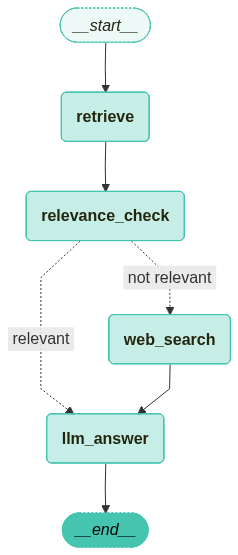

In [16]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(app)

## 그래프 실행

그래프를 실행하여 웹 검색 폴백이 포함된 RAG 파이프라인을 테스트합니다. `invoke_graph`와 `stream_graph` 함수를 사용하여 각각 일괄 실행과 스트리밍 출력을 수행할 수 있습니다. PDF 문서에 없는 최신 정보를 질문하면 관련성 체크가 실패하고, 자동으로 웹 검색을 통해 답변을 생성합니다.

아래 코드에서는 PDF 문서에 없는 최신 정보를 질문하여 웹 검색 폴백을 테스트합니다.

In [ ]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, invoke_graph, random_uuid

# config 설정
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# 질문 입력 (PDF에 없는 최신 정보 - 웹 검색 필요)
inputs = GraphState(question="2024년 노벨 문학상 수상자는?")

# 그래프 실행
invoke_graph(app, inputs, config, node_names=["relevance_check", "llm_answer"])

==== [RELEVANCE CHECK] ====
no

🔄 Node: relevance_check 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
relevance:
no

🔄 Node: llm_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
answer:
2024년 노벨 문학상 수상자는 한강(韓江) 작가입니다.

**Source**  
- https://blog.naver.com/limsang92/223617050377
('user', '2024년 노벨 문학상 수상자는?')
('assistant', '2024년 노벨 문학상 수상자는 한강(韓江) 작가입니다.\n\n**Source**  \n- https://blog.naver.com/limsang92/223617050377')


In [18]:
# 콜백 함수 예시 (특정 노드 출력만 처리)
def callback_function(args):
    if args["node"] == "llm_answer":
        print(args["content"], end="", flush=True)


# 그래프 스트리밍 출력 (콜백 적용)
stream_graph(
    app, inputs, config, node_names=["relevance_check", "llm_answer"], callback=callback_function
)

==== [RELEVANCE CHECK] ====
no
2024년 노벨 문학상 수상자는 한강(韓江) 작가입니다.

**Source**  
- https://blog.naver.com/limsang92/223617050377

### 결과 확인

그래프 실행 후 최종 상태를 확인합니다. `get_state` 메서드를 사용하면 현재 체크포인트에 저장된 모든 상태 값을 조회할 수 있습니다. 질문, 답변과 함께 관련성 체크 결과(`relevance`)도 확인할 수 있습니다.

아래 코드는 최종 상태에서 질문과 답변을 출력합니다.

In [19]:
# 최종 출력 확인
outputs = app.get_state(config).values

print(f'Question: {outputs["question"]}')
print("===" * 20)
print(f'Answer:\n{outputs["answer"]}')

Question: 2024년 노벨 문학상 수상자는?
Answer:
2024년 노벨 문학상 수상자는 한강(韓江) 작가입니다.

**Source**  
- https://blog.naver.com/limsang92/223617050377


## 정리

이 튜토리얼에서는 RAG 파이프라인에 **웹 검색** 기능을 추가했습니다.

### 핵심 개념

1. **TavilySearch**: 웹에서 최신 정보를 검색하는 도구입니다.
2. **폴백 전략**: 관련성 체크 실패 시 웹 검색으로 보완합니다.
3. **재귀 상태 해결**: 웹 검색으로 폴백하여 무한 루프를 방지합니다.

### 다음 단계

다음 튜토리얼에서는 **쿼리 재작성(Query Rewrite)**을 추가하여 검색 품질을 더욱 향상시키는 방법을 학습합니다.